In [136]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [137]:
data = pd.read_csv("Datasets/social_media_addiction_mental_wellbeing.csv")
data.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [138]:
newdata = data[['Gender','Occupation','Primary_Platform','Late_Night_Usage','Addiction_Level']]

newdata

,Gender,Occupation,Primary_Platform,Late_Night_Usage,Addiction_Level
0,Male,Working Professional,YouTube,No,Low
1,Male,Student,Instagram,NaN,Severe
2,Male,Student,YouTube,No,High
3,Female,Student,Facebook,Yes,Severe
4,Non-binary,Student,TikTok,No,Moderate
...,...,...,...,...,...
1495,Male,Working Professional,TikTok,No,High
1496,Non-binary,Student,YouTube,Yes,Moderate
1497,Female,Student,Instagram,Yes,Severe
1498,Female,Freelancer,Twitter/X,Yes,High


In [139]:
newdata.isnull().sum()

Gender              53
Occupation          45
Primary_Platform    53
Late_Night_Usage    50
Addiction_Level      0
dtype: int64

In [140]:
newdata.isnull().mean()*100

Gender              3.533333
Occupation          3.000000
Primary_Platform    3.533333
Late_Night_Usage    3.333333
Addiction_Level     0.000000
dtype: float64

In [141]:
print(newdata['Addiction_Level'].dtype)
print(newdata['Addiction_Level'].head())

str
0         Low
1      Severe
2        High
3      Severe
4    Moderate
Name: Addiction_Level, dtype: str


In [142]:
tempdata1 = newdata['Gender'].fillna(newdata['Gender'].mode()[0])
tempdata2 = newdata['Occupation'].fillna(newdata['Occupation'].mode()[0])
tempdata3 = newdata['Primary_Platform'].fillna(newdata['Primary_Platform'].mode()[0])
tempdata4 = newdata['Late_Night_Usage'].fillna(newdata['Late_Night_Usage'].mode()[0])



IndexError: index 0 is out of bounds for axis 0 with size 0

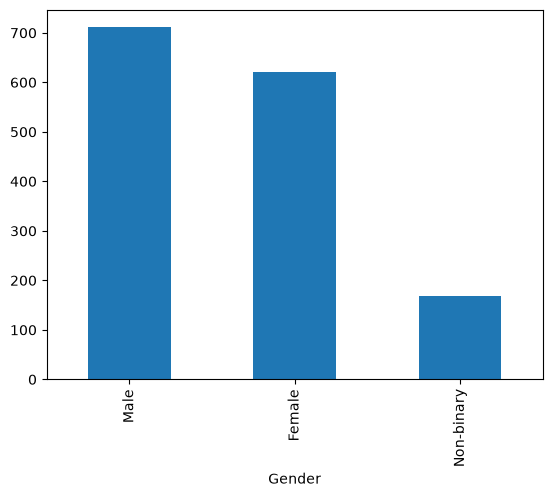

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Convert categorical levels to numbers for KDE
mapping = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}

before_fill = newdata['Addiction_Level'].map(mapping)
after_fill = newdata['Addiction_Level'].fillna(newdata['Addiction_Level'].mode()[0]).map(mapping)

before_fill.dropna().plot(kind='kde', ax=ax, label='Before fillna')
after_fill.dropna().plot(kind='kde', ax=ax, color='red', label='After fillna')

plt.title('KDE plot before and after fillna')
plt.legend()
plt.show()